In [1]:
# !pip uninstall -y torch torchvision torchaudio
# !pip install torch==2.2.2 torchvision==0.17.2 torchaudio==2.2.2

In [2]:
# import os
# os._exit(0)

In [3]:
import os
import copy
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, classification_report
from sklearn.svm import SVC
from tqdm import tqdm
import warnings

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')

In [4]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

torch.manual_seed(42)
np.random.seed(42)

DATA_DIR = '/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset'

Using device: cuda


In [5]:
BATCH_SIZE = 32 * 2
NUM_EPOCHS = 15
LEARNING_RATE = 1e-4
IMG_SIZE = 224

In [6]:

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    
    transforms.RandomHorizontalFlip(p=0.5),
    
    transforms.RandomAffine(
        degrees=15,
        translate=(0.1, 0.1),
        scale=(0.9, 1.1)
    ),
    
    transforms.ColorJitter(
        brightness=0.15,
        contrast=0.15
    ),
    
    transforms.ToTensor(),
    
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    
    transforms.ToTensor(),
    
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

train_dataset = datasets.ImageFolder(
    DATA_DIR + '/Training',
    transform=train_transform
)

test_dataset = datasets.ImageFolder(
    DATA_DIR + '/Testing',
    transform=test_transform
)

class_names = train_dataset.classes
num_classes = len(class_names)

print(f" Classes found: {class_names} ({num_classes} classes)")
print(f" Training images: {len(train_dataset)}")
print(f" Testing images:  {len(test_dataset)}")

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=4,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=4,
    pin_memory=True
)

 Classes found: ['glioma', 'meningioma', 'notumor', 'pituitary'] (4 classes)
 Training images: 5600
 Testing images:  1600


In [7]:
def get_resnet50_classifier(num_classes, freeze_backbone=False):
    model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
    
    num_ftrs = model.fc.in_features
    model.fc = nn.Linear(num_ftrs, num_classes)
    
    if freeze_backbone:
        for name, param in model.named_parameters():
            if "fc" not in name:
                param.requires_grad = False
    
    return model

freeze_backbone = (device.type == 'cpu')

model_e2e = get_resnet50_classifier(
    num_classes,
    freeze_backbone=freeze_backbone
).to(device)

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model_e2e.parameters()),
    lr=LEARNING_RATE
)

scheduler = optim.lr_scheduler.StepLR(
    optimizer,
    step_size=10,
    gamma=0.5
)

train_losses, train_accs = [], []

for epoch in range(NUM_EPOCHS):
    model_e2e.train()
    
    running_loss, correct, total = 0.0, 0, 0
    
    for inputs, targets in tqdm(
        train_loader,
        desc=f"Epoch {epoch+1}/{NUM_EPOCHS}",
        leave=False
    ):
        inputs, targets = inputs.to(device), targets.to(device)
        
        optimizer.zero_grad()
        
        outputs = model_e2e(inputs)
        loss = criterion(outputs, targets)
        
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        
        _, predicted = outputs.max(1)
        
        total += targets.size(0)
        correct += predicted.eq(targets).sum().item()
    
    epoch_loss = running_loss / len(train_loader)
    epoch_acc = correct / total
    
    train_losses.append(epoch_loss)
    train_accs.append(epoch_acc)
    
    scheduler.step()
    
    if (epoch + 1) % 3 == 0 or epoch == 0:
        print(
            f"Epoch {epoch+1:2d} | "
            f"Loss: {epoch_loss:.4f} | "
            f"Acc: {epoch_acc:.4f}"
        )

model_e2e.eval()

preds_e2e, labels_e2e = [], []

with torch.no_grad():
    for inputs, targets in tqdm(test_loader, desc="Evaluating E2E"):
        inputs = inputs.to(device)
        
        outputs = model_e2e(inputs)
        
        _, predicted = outputs.max(1)
        
        preds_e2e.extend(predicted.cpu().numpy())
        labels_e2e.extend(targets.numpy())

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 186MB/s]


Epoch  1 | Loss: 0.4721 | Acc: 0.8468


Epoch  3 | Loss: 0.0774 | Acc: 0.9730


Epoch  6 | Loss: 0.0324 | Acc: 0.9889


Epoch  9 | Loss: 0.0214 | Acc: 0.9927


Epoch 12 | Loss: 0.0079 | Acc: 0.9980


Epoch 15 | Loss: 0.0098 | Acc: 0.9973


Evaluating E2E: 100%|██████████| 25/25 [00:05<00:00,  4.32it/s]


In [8]:

class PretrainedFeatureExtractor(nn.Module):
    def __init__(self):
        super().__init__()
        
        base_model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
        
        self.feature_extractor = nn.Sequential(
            *list(base_model.children())[:-1]
        )
        
        self.flatten = nn.Flatten()

    def forward(self, x):
        x = self.feature_extractor(x)
        x = self.flatten(x)
        return x

pretrained_extractor = PretrainedFeatureExtractor().to(device)
pretrained_extractor.eval()

def extract_pretrained_features(loader, model, device):
    features, labels = [], []
    
    with torch.no_grad():
        for inputs, targets in tqdm(
            loader,
            desc="Extracting pretrained features",
            leave=False
        ):
            inputs = inputs.to(device)
            
            feats = model(inputs)
            
            features.append(feats.cpu().numpy())
            labels.append(targets.numpy())
    
    return np.vstack(features), np.concatenate(labels)

print("📥 Extracting 2048 features from pretrained ResNet50")

X_train_pre, y_train_pre = extract_pretrained_features(
    train_loader,
    pretrained_extractor,
    device
)

X_test_pre, y_test_pre = extract_pretrained_features(
    test_loader,
    pretrained_extractor,
    device
)

print(
    f" train features shape: {X_train_pre.shape} | "
    f"test features shape: {X_test_pre.shape}"
)

clf_svm_pre = SVC(
    kernel='rbf',
    C=1.0,
    gamma='scale',
    probability=True,
    random_state=42
)

clf_svm_pre.fit(X_train_pre, y_train_pre)

preds_svm_pre = clf_svm_pre.predict(X_test_pre)

print("(Pretrained Features + SVM) complete")

📥 Extracting 2048 features from pretrained ResNet50


 train features shape: (5600, 2048) | test features shape: (1600, 2048)
(Pretrained Features + SVM) complete


In [9]:

class FineTunedFeatureExtractor(nn.Module):
    def __init__(self, trained_model):
        super().__init__()
        
        self.feature_extractor = nn.Sequential(
            *list(trained_model.children())[:-1]
        )
        
        self.flatten = nn.Flatten()

    def forward(self, x):
        x = self.feature_extractor(x)
        x = self.flatten(x)
        return x

ft_extractor = FineTunedFeatureExtractor(model_e2e).to(device)
ft_extractor.eval()

def extract_finetuned_features(loader, model, device):
    features, labels = [], []
    
    with torch.no_grad():
        for inputs, targets in tqdm(
            loader,
            desc="Extracting fine-tuned features",
            leave=False
        ):
            inputs = inputs.to(device)
            
            feats = model(inputs)
            
            features.append(feats.cpu().numpy())
            labels.append(targets.numpy())
    
    return np.vstack(features), np.concatenate(labels)

print("📥 Extracting 2048 features from the fine tuned model (E2E)")

X_train_ft, y_train_ft = extract_finetuned_features(
    train_loader,
    ft_extractor,
    device
)

X_test_ft, y_test_ft = extract_finetuned_features(
    test_loader,
    ft_extractor,
    device
)

print(
    f" train features shape: {X_train_ft.shape} | "
    f"test features shape: {X_test_ft.shape}"
)

clf_svm_ft = SVC(
    kernel='rbf',
    C=1.0,
    gamma='scale',
    probability=True,
    random_state=42
)

clf_svm_ft.fit(X_train_ft, y_train_ft)

preds_svm_ft = clf_svm_ft.predict(X_test_ft)

print("(Fine-Tuned Features + SVM) complete")

📥 Extracting 2048 features from the fine tuned model (E2E)


 train features shape: (5600, 2048) | test features shape: (1600, 2048)
(Fine-Tuned Features + SVM) complete



 FINAL TEST RESULTS

 Approach-1 (Pretrained Features + SVM):
   Accuracy: 0.8231 | Precision: 0.8396
   Recall:   0.8231 | F1-Score:  0.8159

 Approach-2 (E2E):
   Accuracy: 0.9556 | Precision: 0.9594
   Recall:   0.9556 | F1-Score:  0.9545

 Approach-3 (Fine-Tuned Features + SVM):
   Accuracy: 0.9537 | Precision: 0.9575
   Recall:   0.9537 | F1-Score:  0.9526

 Per-Class Report (Approach-1 - Pretrained + SVM):
              precision    recall  f1-score   support

      glioma       0.95      0.58      0.72       400
  meningioma       0.74      0.75      0.75       400
     notumor       0.76      0.99      0.86       400
   pituitary       0.90      0.96      0.93       400

    accuracy                           0.82      1600
   macro avg       0.84      0.82      0.82      1600
weighted avg       0.84      0.82      0.82      1600


 Per-Class Report (Approach-2 - E2E):
              precision    recall  f1-score   support

      glioma       1.00      0.82      0.90       400


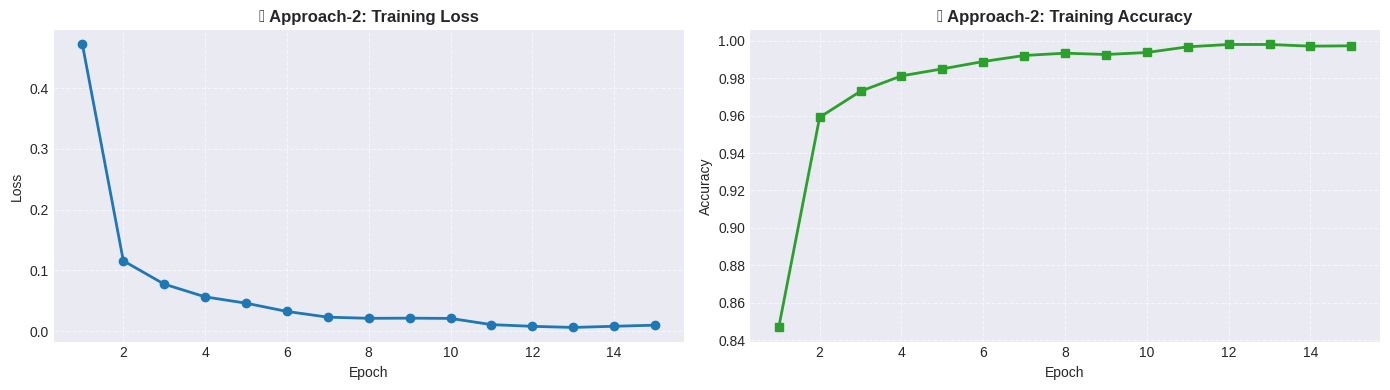

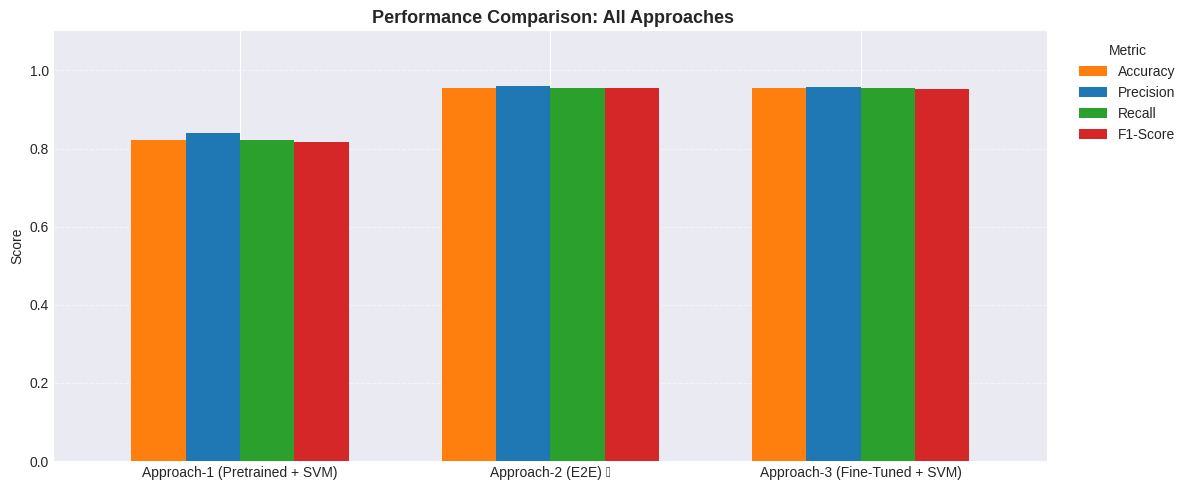

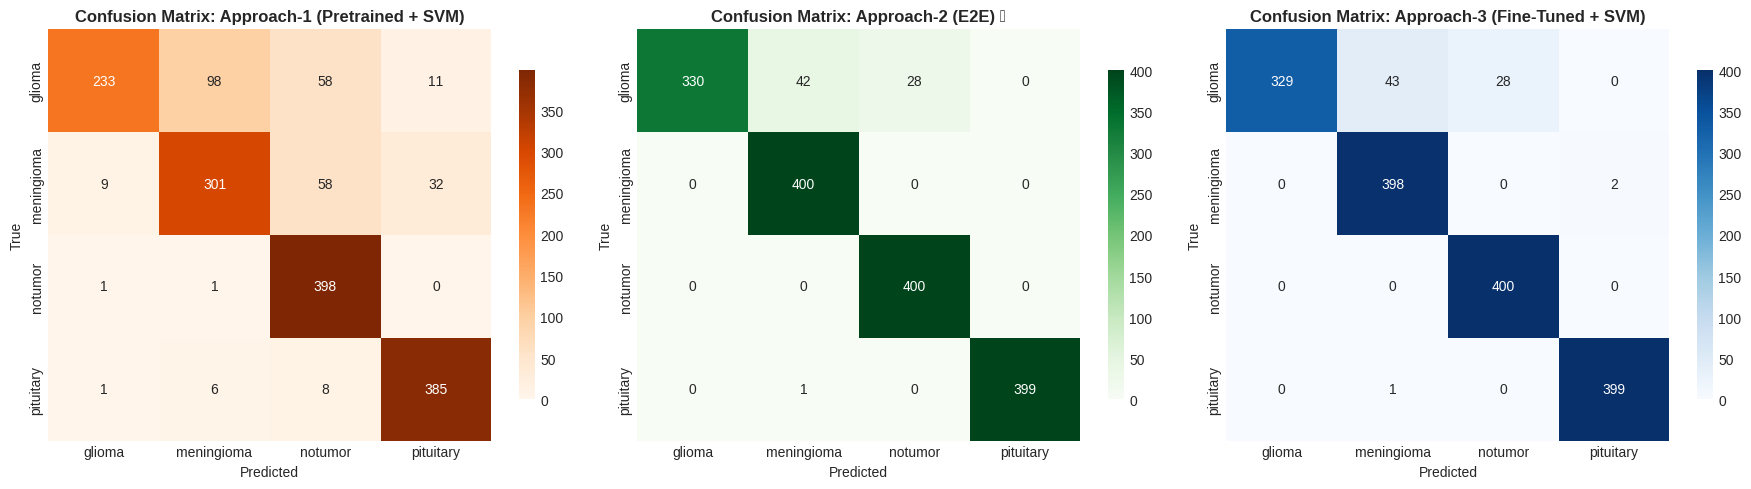

 Saved: brain_tumor_predictions_resnet50.csv
 Saved trained E2E model: resnet50_brain_tumor_trained.pth


In [10]:
import pandas as pd

def compute_metrics(y_true, y_pred, class_names):
    acc = accuracy_score(y_true, y_pred)
    
    prec, rec, f1, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        average='weighted'
    )
    
    cm = confusion_matrix(y_true, y_pred)
    
    return {
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1
    }, cm

metrics_e2e, cm_e2e = compute_metrics(
    labels_e2e,
    preds_e2e,
    class_names
)

metrics_svm_pre, cm_svm_pre = compute_metrics(
    y_test_pre,
    preds_svm_pre,
    class_names
)

metrics_svm_ft, cm_svm_ft = compute_metrics(
    y_test_ft,
    preds_svm_ft,
    class_names
)

print("\n" + "="*70)
print(" FINAL TEST RESULTS")
print("="*70)

print(f"\n Approach-1 (Pretrained Features + SVM):")

print(
    f"   Accuracy: {metrics_svm_pre['Accuracy']:.4f} | "
    f"Precision: {metrics_svm_pre['Precision']:.4f}"
)

print(
    f"   Recall:   {metrics_svm_pre['Recall']:.4f} | "
    f"F1-Score:  {metrics_svm_pre['F1-Score']:.4f}"
)

print(f"\n Approach-2 (E2E):")

print(
    f"   Accuracy: {metrics_e2e['Accuracy']:.4f} | "
    f"Precision: {metrics_e2e['Precision']:.4f}"
)

print(
    f"   Recall:   {metrics_e2e['Recall']:.4f} | "
    f"F1-Score:  {metrics_e2e['F1-Score']:.4f}"
)

print(f"\n Approach-3 (Fine-Tuned Features + SVM):")

print(
    f"   Accuracy: {metrics_svm_ft['Accuracy']:.4f} | "
    f"Precision: {metrics_svm_ft['Precision']:.4f}"
)

print(
    f"   Recall:   {metrics_svm_ft['Recall']:.4f} | "
    f"F1-Score:  {metrics_svm_ft['F1-Score']:.4f}"
)

print("="*70)

print(f"\n Per-Class Report (Approach-1 - Pretrained + SVM):")

print(
    classification_report(
        y_test_pre,
        preds_svm_pre,
        target_names=class_names
    )
)

print(f"\n Per-Class Report (Approach-2 - E2E):")

print(
    classification_report(
        labels_e2e,
        preds_e2e,
        target_names=class_names
    )
)

print(f"\n Per-Class Report (Approach-3 - Fine-Tuned + SVM):")

print(
    classification_report(
        y_test_ft,
        preds_svm_ft,
        target_names=class_names
    )
)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(
    range(1, NUM_EPOCHS+1),
    train_losses,
    marker='o',
    color='#1f77b4',
    linewidth=2
)

axes[0].set_title(
    '🔹 Approach-2: Training Loss',
    fontweight='bold'
)

axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].grid(True, ls='--', alpha=0.6)

axes[1].plot(
    range(1, NUM_EPOCHS+1),
    train_accs,
    marker='s',
    color='#2ca02c',
    linewidth=2
)

axes[1].set_title(
    '🔹 Approach-2: Training Accuracy',
    fontweight='bold'
)

axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].grid(True, ls='--', alpha=0.6)

plt.tight_layout()
plt.show()

metrics_df = pd.DataFrame({
    'Accuracy': [
        metrics_svm_pre['Accuracy'],
        metrics_e2e['Accuracy'],
        metrics_svm_ft['Accuracy']
    ],
    
    'Precision': [
        metrics_svm_pre['Precision'],
        metrics_e2e['Precision'],
        metrics_svm_ft['Precision']
    ],
    
    'Recall': [
        metrics_svm_pre['Recall'],
        metrics_e2e['Recall'],
        metrics_svm_ft['Recall']
    ],
    
    'F1-Score': [
        metrics_svm_pre['F1-Score'],
        metrics_e2e['F1-Score'],
        metrics_svm_ft['F1-Score']
    ]
}, index=[
    'Approach-1 (Pretrained + SVM)',
    'Approach-2 (E2E) ★',
    'Approach-3 (Fine-Tuned + SVM)'
])

fig, ax = plt.subplots(figsize=(12, 5))

metrics_df.plot(
    kind='bar',
    ax=ax,
    color=['#ff7f0e', '#1f77b4', '#2ca02c', '#d62728'],
    width=0.7
)

ax.set_title(
    ' Performance Comparison: All Approaches',
    fontweight='bold',
    fontsize=13
)

ax.set_ylabel('Score')
ax.set_ylim(0, 1.1)

ax.grid(axis='y', ls='--', alpha=0.5)
ax.set_axisbelow(True)

ax.legend(
    title='Metric',
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)

plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

def plot_cm(cm, ax, title, classes, cmap):
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap=cmap,
        ax=ax,
        cbar_kws={'shrink':0.8},
        xticklabels=classes,
        yticklabels=classes
    )
    
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    ax.set_title(title, fontweight='bold')

plot_cm(
    cm_svm_pre,
    axes[0],
    'Confusion Matrix: Approach-1 (Pretrained + SVM)',
    class_names,
    'Oranges'
)

plot_cm(
    cm_e2e,
    axes[1],
    'Confusion Matrix: Approach-2 (E2E) ★',
    class_names,
    'Greens'
)

plot_cm(
    cm_svm_ft,
    axes[2],
    'Confusion Matrix: Approach-3 (Fine-Tuned + SVM)',
    class_names,
    'Blues'
)

plt.tight_layout()
plt.show()

results = pd.DataFrame({
    'True_Label': labels_e2e,
    'Pred_Pretrained_SVM': preds_svm_pre,
    'Pred_E2E': preds_e2e,
    'Pred_FT_SVM': preds_svm_ft,
    'Class_Name': [class_names[i] for i in labels_e2e]
})

results.to_csv('brain_tumor_predictions_resnet50.csv', index=False)

print(" Saved: brain_tumor_predictions_resnet50.csv")

if device.type == 'cuda':
    torch.save({
        'model_state': model_e2e.state_dict(),
        'test_acc_pretrained_svm': metrics_svm_pre['Accuracy'],
        'test_acc_e2e': metrics_e2e['Accuracy'],
        'test_acc_ft_svm': metrics_svm_ft['Accuracy'],
        'classes': class_names
    }, 'resnet50_brain_tumor_trained.pth')
    
    print(" Saved trained E2E model: resnet50_brain_tumor_trained.pth")

In [11]:

import pandas as pd
from IPython.display import display

metrics_table = pd.DataFrame({
    'Approach-1 (Pretrained + SVM)': [
        metrics_svm_pre['Accuracy'],
        metrics_svm_pre['Precision'],
        metrics_svm_pre['Recall'],
        metrics_svm_pre['F1-Score']
    ],
    
    'Approach-2 (E2E)': [
        metrics_e2e['Accuracy'],
        metrics_e2e['Precision'],
        metrics_e2e['Recall'],
        metrics_e2e['F1-Score']
    ],
    
    'Approach-3 (Fine-Tuned + SVM)': [
        metrics_svm_ft['Accuracy'],
        metrics_svm_ft['Precision'],
        metrics_svm_ft['Recall'],
        metrics_svm_ft['F1-Score']
    ]
}, index=[
    'Accuracy',
    'Precision',
    'Recall',
    'F1-Score'
])

metrics_table['Δ (E2E - Pretrained SVM)'] = (
    metrics_table['Approach-2 (E2E)'] -
    metrics_table['Approach-1 (Pretrained + SVM)']
)

metrics_table['Δ (E2E - FineTuned SVM)'] = (
    metrics_table['Approach-2 (E2E)'] -
    metrics_table['Approach-3 (Fine-Tuned + SVM)']
)

metrics_table = metrics_table.round(4)

print("\n" + "="*80)
print(" COMPARATIVE METRICS SUMMARY")
print("="*80)

display(metrics_table)

print("\n" + "-"*120)

print(
    f"{'Metric':<14} | "
    f"{'Pretrained+SVM':>16} | "
    f"{'E2E':>10} | "
    f"{'FineTuned+SVM':>18} | "
    f"{'Δ(E2E-Pre)':>12} | "
    f"{'Δ(E2E-FT)':>12}"
)

print("-"*120)

for idx, row in metrics_table.iterrows():
    diff_pre = row['Δ (E2E - Pretrained SVM)']
    diff_ft = row['Δ (E2E - FineTuned SVM)']
    
    diff_pre_str = (
        f"+{diff_pre:.4f}"
        if diff_pre >= 0
        else f"{diff_pre:.4f}"
    )
    
    diff_ft_str = (
        f"+{diff_ft:.4f}"
        if diff_ft >= 0
        else f"{diff_ft:.4f}"
    )
    
    print(
        f"{idx:<14} | "
        f"{row['Approach-1 (Pretrained + SVM)']:>16.4f} | "
        f"{row['Approach-2 (E2E)']:>10.4f} | "
        f"{row['Approach-3 (Fine-Tuned + SVM)']:>18.4f} | "
        f"{diff_pre_str:>12} | "
        f"{diff_ft_str:>12}"
    )

print("="*120)


 COMPARATIVE METRICS SUMMARY


,Approach-1 (Pretrained + SVM),Approach-2 (E2E),Approach-3 (Fine-Tuned + SVM),Δ (E2E - Pretrained SVM),Δ (E2E - FineTuned SVM)
Accuracy,0.8231,0.9556,0.9538,0.1325,0.0019
Precision,0.8396,0.9594,0.9575,0.1198,0.0019
Recall,0.8231,0.9556,0.9538,0.1325,0.0019
F1-Score,0.8159,0.9545,0.9526,0.1386,0.0019



------------------------------------------------------------------------------------------------------------------------
Metric         |   Pretrained+SVM |        E2E |      FineTuned+SVM |   Δ(E2E-Pre) |    Δ(E2E-FT)
------------------------------------------------------------------------------------------------------------------------
Accuracy       |           0.8231 |     0.9556 |             0.9538 |      +0.1325 |      +0.0019
Precision      |           0.8396 |     0.9594 |             0.9575 |      +0.1198 |      +0.0019
Recall         |           0.8231 |     0.9556 |             0.9538 |      +0.1325 |      +0.0019
F1-Score       |           0.8159 |     0.9545 |             0.9526 |      +0.1386 |      +0.0019
